# Creating a Uniform Grid {#create_uniform_grid_exercise}

Create a simple uniform grid from a 3D NumPy array of values.


In [1]:
import numpy as np
import pyvista as pv

c:\Users\Usuario\anaconda3\envs\VAD\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Take a 3D NumPy array of data values that holds some spatial data where
each axis corresponds to the XYZ cartesian axes. This example will
create a `pyvista.ImageData`{.interpreted-text role="class"} that will
hold the spatial reference for a 3D grid by which a 3D NumPy array of
values can be plotted against.


Create the 3D NumPy array of spatially referenced data. This is
spatially referenced such that the grid is `(20, 5, 10)`,
`(nx, ny, nz)`.


In [2]:
values = np.linspace(0, 10, 1000).reshape((20, 5, 10))
values.shape

(20, 5, 10)

Create the ImageData


In [3]:
grid = pv.ImageData()

Set the grid dimensions to `shape + 1` because we want to inject our
values on the CELL data.


In [4]:
grid.dimensions = np.array(values.shape) + 1

Edit the spatial reference.


In [5]:
grid.origin = (100, 33, 55.6)  # The bottom left corner of the data set
grid.spacing = (1, 5, 2)  # These are the cell sizes along each axis

Assign the data to the cell data. Be sure to flatten the data for
`ImageData` objects using Fortran ordering.


In [6]:
grid.cell_data["values"] = values.flatten(order="F")
grid

ImageData (0x2d9c6a19d80)
  N Cells:      1000
  N Points:     1386
  X Bounds:     1.000e+02, 1.200e+02
  Y Bounds:     3.300e+01, 5.800e+01
  Z Bounds:     5.560e+01, 7.560e+01
  Dimensions:   21, 6, 11
  Spacing:      1.000e+00, 5.000e+00, 2.000e+00
  N Arrays:     1

Now plot the grid!


C:\Users\Usuario\AppData\Local\Temp\ipykernel_7836\842823931.py:1: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  grid.plot(show_edges=True)


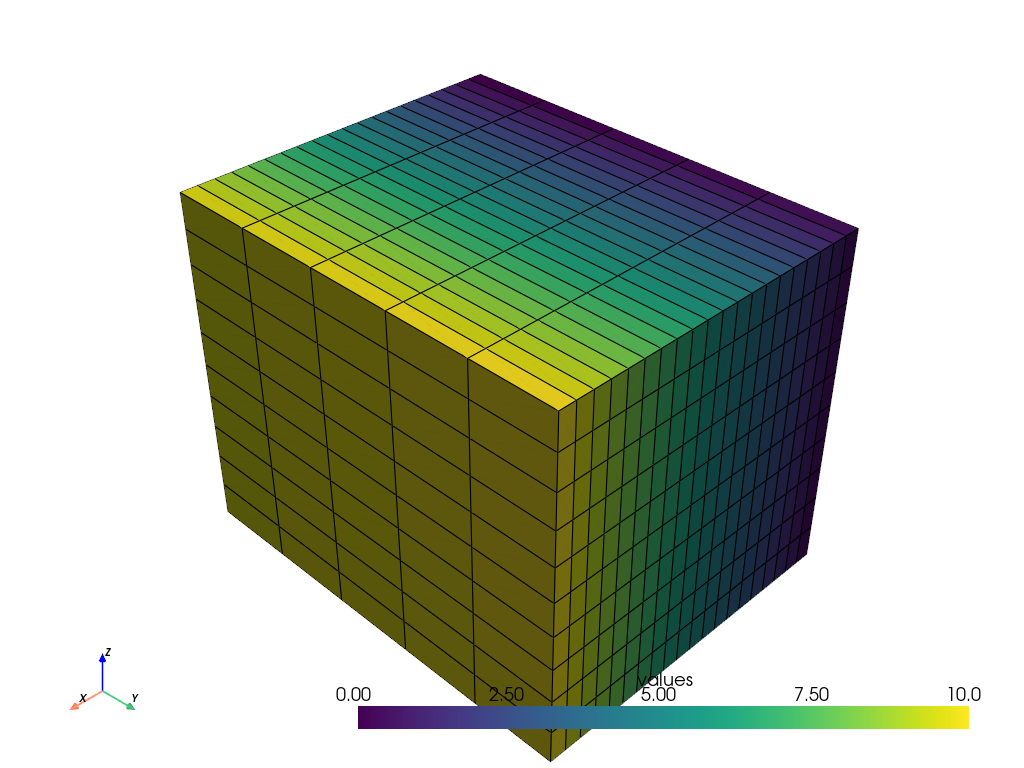

In [7]:
grid.plot(show_edges=True)

Don\'t like cell data? You could also add the NumPy array to the point
data of a `pyvista.ImageData`{.interpreted-text role="class"}. Take note
of the subtle difference when setting the grid dimensions upon
initialization.


In [8]:
# Create the 3D NumPy array of spatially referenced data again.
values = np.linspace(0, 10, 1000).reshape((20, 5, 10))
values.shape

(20, 5, 10)

Create the PyVista object and set the same attributes as earlier.


In [9]:
grid = pv.ImageData()

# Set the grid dimensions to ``shape`` because we want to inject our values on
# the POINT data
grid.dimensions = values.shape

# Edit the spatial reference
grid.origin = (100, 33, 55.6)  # The bottom left corner of the data set
grid.spacing = (1, 5, 2)  # These are the cell sizes along each axis

Add the data values to the cell data


In [10]:
grid.point_data["values"] = values.flatten(order="F")  # Flatten the array!
grid

ImageData (0x2d9ca91abc0)
  N Cells:      684
  N Points:     1000
  X Bounds:     1.000e+02, 1.190e+02
  Y Bounds:     3.300e+01, 5.300e+01
  Z Bounds:     5.560e+01, 7.360e+01
  Dimensions:   20, 5, 10
  Spacing:      1.000e+00, 5.000e+00, 2.000e+00
  N Arrays:     1

Now plot the grid!


C:\Users\Usuario\AppData\Local\Temp\ipykernel_7836\842823931.py:1: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  grid.plot(show_edges=True)


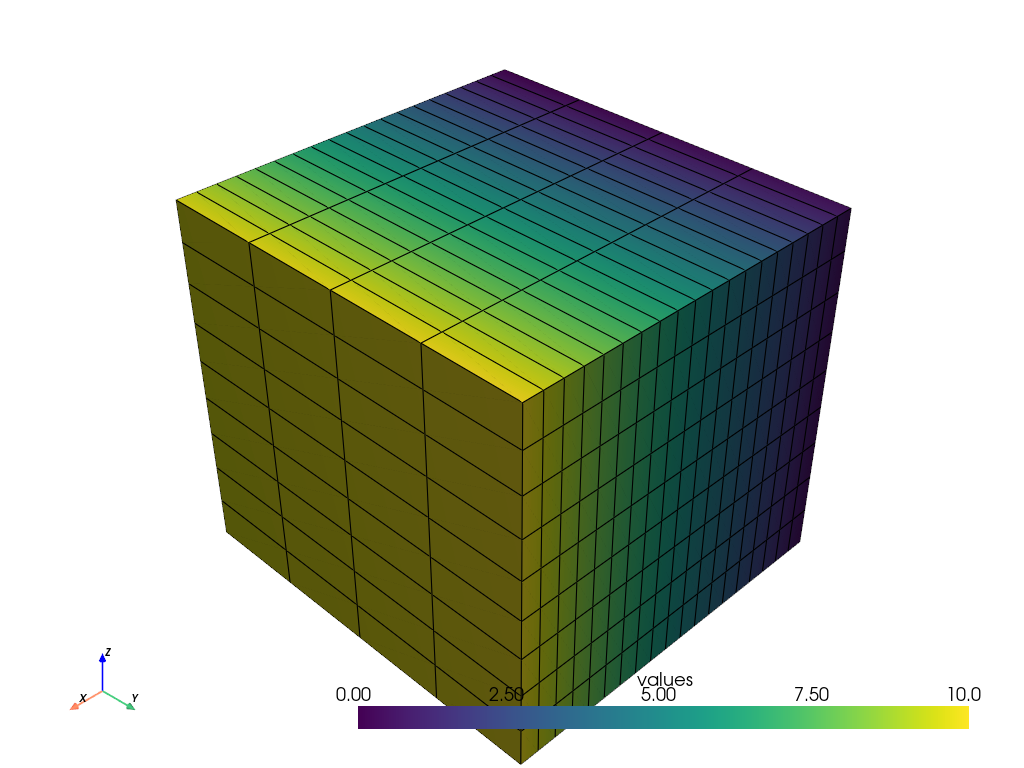

In [11]:
grid.plot(show_edges=True)

# Exercise

Now create your own `pyvista.ImageData`{.interpreted-text role="class"}
from a 3D NumPy array!


In [ ]:
help(pv.ImageData)

Generate example 3D data using `numpy.random.random`{.interpreted-text
role="func"}. Feel free to use your own 3D numpy array here.


In [14]:
arr = np.random.random((100, 100, 100))
arr.shape

(100, 100, 100)

Create the `pyvista.ImageData`{.interpreted-text role="class"}.

::: note
::: title
Note
:::

You will likely need to `ravel` the array with Fortran-ordering:
`arr.ravel(order="F")`
:::


In [17]:
vol = pv.ImageData()

# Set attributes and data
vol.dimensions = arr.shape
vol.point_data["values"] = arr.ravel(order="F")  # Flatten the array!
vol

ImageData (0x2da1d9044c0)
  N Cells:      970299
  N Points:     1000000
  X Bounds:     0.000e+00, 9.900e+01
  Y Bounds:     0.000e+00, 9.900e+01
  Z Bounds:     0.000e+00, 9.900e+01
  Dimensions:   100, 100, 100
  Spacing:      1.000e+00, 1.000e+00, 1.000e+00
  N Arrays:     1

Plot the ImageData


C:\Users\Usuario\AppData\Local\Temp\ipykernel_7836\670884378.py:1: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  vol.plot()


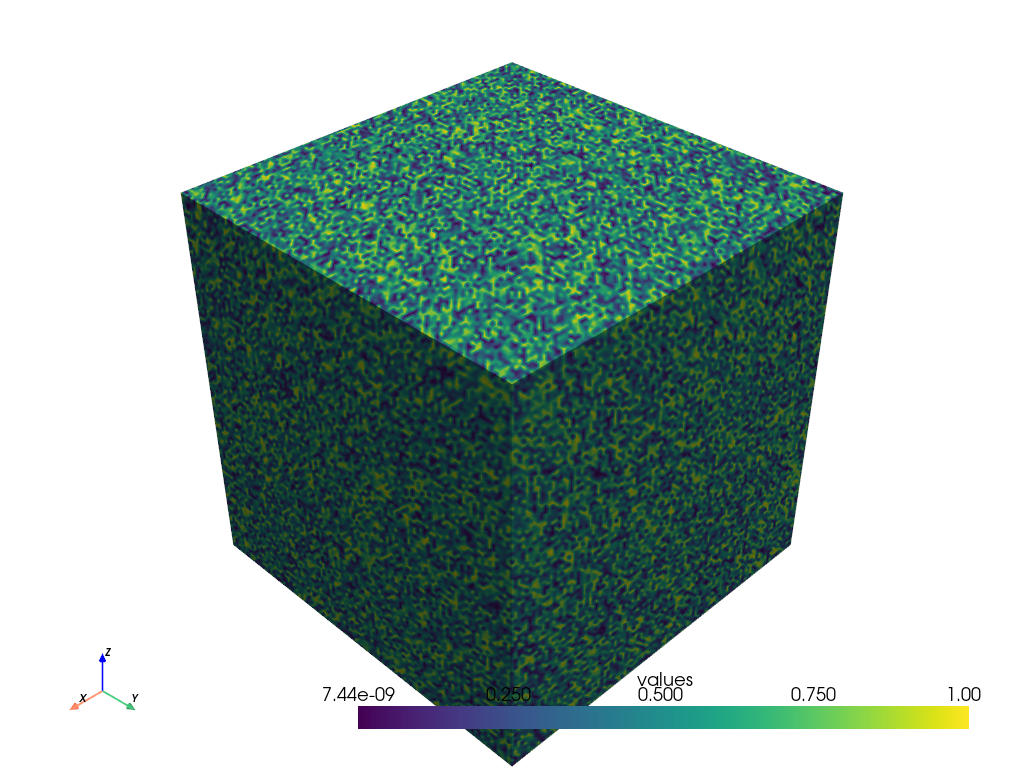

In [18]:
vol.plot()

# Example

PyVista has several examples that use `ImageData`.

See the PyVista documentation for further details on [Volume
Rendering](https://docs.pyvista.org/examples/02-plot/volume.html)

Here\'s one of these example datasets:


C:\Users\Usuario\AppData\Local\Temp\ipykernel_7836\2834816334.py:7: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  pl.show()


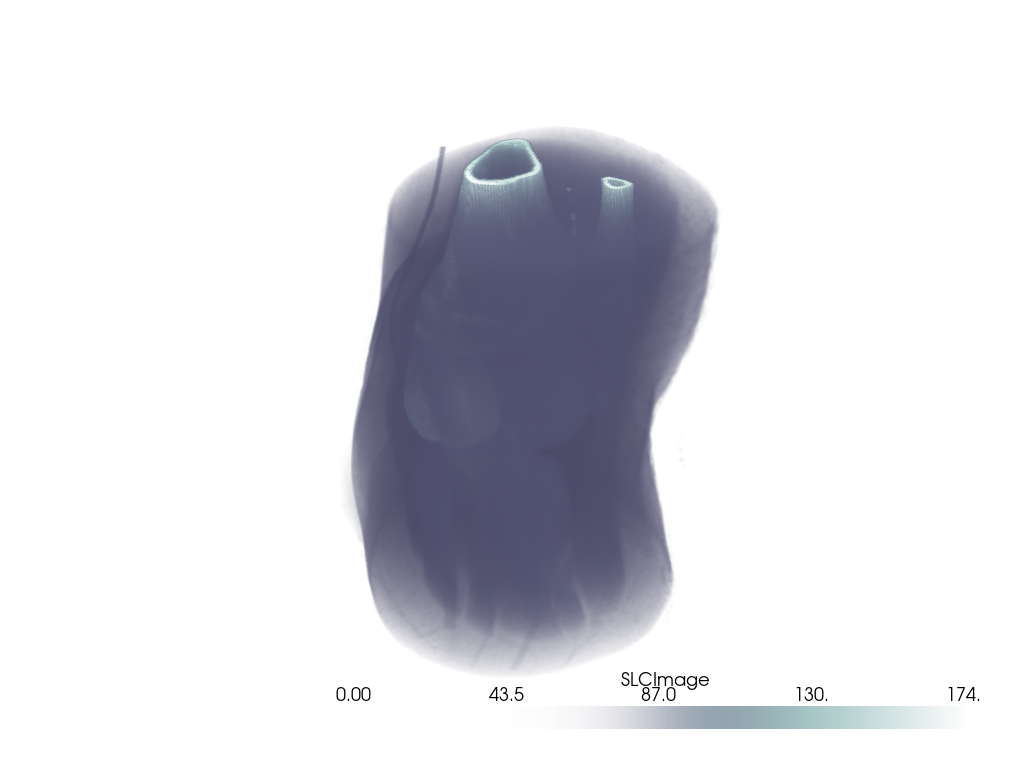

In [19]:
from pyvista import examples

vol = examples.download_knee_full()

pl = pv.Plotter()
pl.add_volume(vol, cmap="bone", opacity="sigmoid")
pl.show()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_7836\3851210585.py:2: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  vol.plot(volume=True)


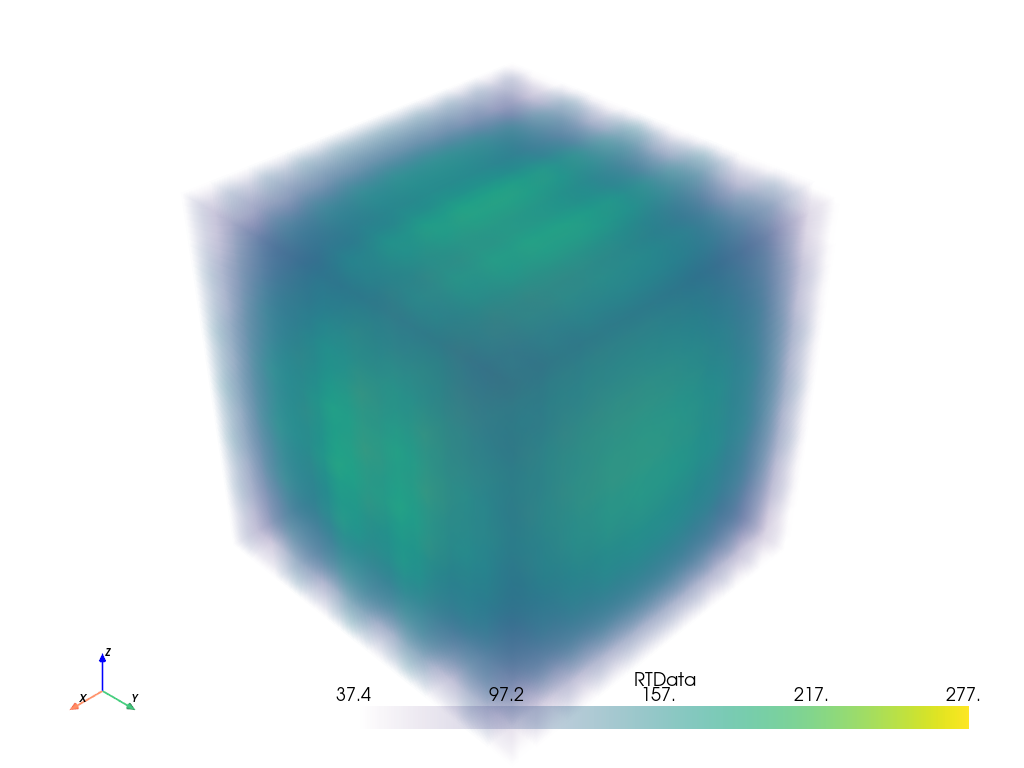

In [20]:
vol = pv.Wavelet()
vol.plot(volume=True)

```{=html}
<center>
  <a target="_blank" href="https://colab.research.google.com/github/pyvista/pyvista-tutorial/blob/gh-pages/notebooks/tutorial/02_mesh/exercises/c_create-uniform-grid.ipynb">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/ width="150px">
  </a>
</center>
```
